# 🛰️ Oil-Spill Culprit Attribution — Reverse Lagrangian Hindcasting + AIS Interception

**Pipeline:** satellite slick mask → particle seeding → reverse Lagrangian transport (ERA5 wind + CMEMS currents) → rolling 95 % KDE origin envelopes → AIS spatio-temporal interception → ranked suspect vessels → interactive map.

**Method summary**

$$\frac{d\vec{x}}{dt} = -\big(\vec{u}_{\text{current}} + \alpha\,\vec{u}_{\text{wind}}\big) + \vec{R},\qquad
\vec{R} = \sqrt{\tfrac{6D}{\Delta t}}\;\mathcal{U}(-1,1)$$

with $\alpha \approx 0.03$ (wind leeway) and $D \approx 1\text{–}10\ \mathrm{m^2\,s^{-1}}$ (Abascal et al., 2012; Dagestad et al., 2018 — OpenDrift). Origin envelopes follow Parzen (1962) / Silverman (1986) Gaussian KDE.

**How to use this notebook**
1. Run **Cell 1** (installs + `CFG` dictionary). Edit `CFG` — file paths, credentials, physics parameters — in one place.
2. Upload `oil_mask.tif` and your AIS file to `/content/data/` (or leave `DEMO_MODE=True` to auto-generate synthetic inputs so the whole pipeline runs without any data or credentials).
3. Run Cells 2 → 9 in order. Every cell is idempotent and re-runnable.

> ⚠️ **Data-latency notes:** ERA5 is published with ~5-day latency (ERA5T covers the gap). The CMEMS `anfc` analysis/forecast product covers the last ~2 years and forecasts ~10 days ahead. If credentials are missing, the notebook falls back to clearly-labelled **synthetic** forcing so you can still validate the workflow.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 1 — Environment Setup & Dependencies

Installs the geospatial / met-ocean stack. On Colab this takes ~1–2 min. Restart is **not** required.

| Package | Role |
|---|---|
| `rasterio`, `pyproj` | GeoTIFF I/O, reprojection |
| `geopandas`, `shapely` ≥ 2.0 | Vector geometry, vectorised point-in-polygon |
| `cdsapi` ≥ 0.7 | ERA5 winds (new CDS API, token-based) |
| `copernicusmarine` ≥ 2.0 | CMEMS surface currents |
| `xarray`, `netcdf4` | Gridded forcing datasets |
| `scipy`, `scikit-learn`, `contourpy` | RK4, KDE, PCA, marching-squares contours |
| `duckdb`, `pyarrow` | Out-of-core AIS filtering |
| `folium`, `branca`, `matplotlib` | Visualisation |

In [ ]:
# ── Cell 1 (a): package installation ─────────────────────────────────────────
import sys, subprocess, importlib

PKGS = [
    "rasterio", "geopandas", "shapely>=2.0", "pyproj",
    "cdsapi>=0.7.2", "copernicusmarine>=2.0",
    "xarray", "netcdf4", "scipy", "scikit-learn", "contourpy",
    "duckdb", "pyarrow", "folium", "branca", "matplotlib", "pandas", "numpy",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PKGS], check=False)

# Sanity-check imports and report versions
_report = {}
for mod in ["rasterio", "geopandas", "shapely", "xarray", "scipy", "duckdb", "folium", "cdsapi", "copernicusmarine"]:
    try:
        m = importlib.import_module(mod)
        _report[mod] = getattr(m, "__version__", "ok")
    except Exception as e:                       # cdsapi / copernicusmarine are optional at runtime
        _report[mod] = f"NOT AVAILABLE ({type(e).__name__})"
print("Environment check:")
for k, v in _report.items():
    print(f"  {k:<18} {v}")

Environment check:
  rasterio           1.5.1
  geopandas          1.1.4
  shapely            2.1.2
  xarray             2025.12.0
  scipy              1.16.3
  duckdb             1.3.2
  folium             0.20.0
  cdsapi             ok
  copernicusmarine   2.4.1


### Cell 1 (b) — Global configuration (`CFG`)

**This is the only place you need to edit.** Everything downstream reads from `CFG`.

* `CDS_API_KEY` → your **Personal Access Token** from <https://cds.climate.copernicus.eu/profile> (new CDS, 2024+).
* `CMEMS_USERNAME / CMEMS_PASSWORD` → free account at <https://data.marine.copernicus.eu/register>.
* Leave credentials as placeholders and set `DEMO_MODE=True` to run entirely on synthetic data.

In [ ]:
# ── Cell 1 (b): global configuration ─────────────────────────────────────────
import os, pathlib
import numpy as np
import pandas as pd

CFG = {
    # ── Input files ───────────────────────────────────────────────────────
    "DATA_DIR":        "/content/data",           # all inputs/outputs live here
    "OIL_MASK_PATH":   "/content/data/00004-2.tif",
    "AIS_PATH":        "/content/data/ais.parquet",   # .parquet or .csv
    "T0_OVERRIDE":     None,                      # e.g. "2026-08-21T05:47:00Z" — overrides metadata/filename parsing
    "DEMO_MODE":       True,                      # if inputs are missing, synthesise a demo slick + AIS so the pipeline runs

    # ── Credentials (INSERT YOUR KEYS HERE) ───────────────────────────────
    "CDS_API_KEY":     "f2c49dc6-cb03-4315-9aa6-522cf3b39ef4",
    "CMEMS_USERNAME":  "visheshverma2007@icloud.com",
    "CMEMS_PASSWORD":  "Vivii@161107",
    "CMEMS_DATASET_ID": "cmems_mod_glo_phy_anfc_0.083deg_PT1H-m",   # global 1/12°, hourly surface fields

    # ── Physics / numerics ────────────────────────────────────────────────
    "HOURS_BACK":      24,        # hindcast horizon (24 or 48)
    "DT_SEC":          -600,      # integrator step (negative = backward in time)
    "N_PARTICLES":     2500,
    "ALPHA_WIND":      0.03,      # wind leeway factor
    "D_DIFF":          1.0,       # horizontal eddy diffusivity [m²/s], 1–10
    "BBOX_PAD_DEG":    1.0,       # forcing bbox padding around the slick
    "RANDOM_SEED":     42,

    # ── KDE ───────────────────────────────────────────────────────────────
    "KDE_BW":          "silverman",   # 'scott' | 'silverman' | float
    "KDE_LEVEL":       0.95,
    "KDE_GRID_N":      220,

    # ── AIS ───────────────────────────────────────────────────────────────
    "AIS_COLUMNS": {"mmsi": "mmsi", "timestamp": "timestamp",
                    "lat": "latitude", "lon": "longitude", "sog": "sog", "cog": "cog"},
    "AIS_TS_IS_EPOCH_SECONDS": False,   # True if `timestamp` is a UNIX epoch (s) instead of an ISO string
    "AIS_MAX_GAP_SEC":  2 * 3600,       # max gap between pings to allow position interpolation
    "AIS_MIN_PINGS":    2,

    # ── Scoring weights (must sum to 1) ───────────────────────────────────
    "W_SPATIAL": 0.45, "W_TEMPORAL": 0.20, "W_COURSE": 0.20, "W_SPEED": 0.15,
    "TOP_N_SUSPECTS": 10,
}

pathlib.Path(CFG["DATA_DIR"]).mkdir(parents=True, exist_ok=True)
assert abs(CFG["W_SPATIAL"] + CFG["W_TEMPORAL"] + CFG["W_COURSE"] + CFG["W_SPEED"] - 1) < 1e-9, "weights must sum to 1"
RNG = np.random.default_rng(CFG["RANDOM_SEED"])
print("CFG loaded. DATA_DIR =", CFG["DATA_DIR"])

CFG loaded. DATA_DIR = /content/data


## Cell 2 — Ingestion & Vectorisation of the GeoTIFF Mask

1. Open the mask with `rasterio`; reproject to **EPSG:4326** with nearest-neighbour resampling if the CRS differs.
2. Binarise (highest class = slick; `nodata` → 0) and vectorise with `rasterio.features.shapes` (marching squares on raster cells) → `unary_union` → a single `Polygon` / `MultiPolygon`.
3. Parse $T_0$ from raster tags (`TIFFTAG_DATETIME`, `ACQUISITION_TIME`, …), then from the filename (`YYYYMMDDTHHMMSS`, `YYYY-MM-DD_HH-MM-SS`, …), then `CFG["T0_OVERRIDE"]`, then interactive input.
4. Geometry in a **local UTM** projection: area, perimeter, PCA principal-axis bearing, minimum rotated rectangle (MRR) length / width / bearing, elongation ratio.

*Bearings are reported as azimuths (° clockwise from North, modulo 180 — the slick axis has no direction).*

In [ ]:
# ── Cell 1 (c): auto-georeference the mask if CRS / timestamp are missing ────
import rasterio, numpy as np
from rasterio.transform import from_bounds

ASSUMED_CENTER_LON, ASSUMED_CENTER_LAT = 18.30, 37.95   # open water used if the tif has no CRS
ASSUMED_PIXEL_DEG = 0.0002                              # ~20 m pixels — adjust if your image is coarser/finer

src_path = CFG["OIL_MASK_PATH"]
with rasterio.open(src_path) as src:
    has_crs = src.crs is not None and src.transform.is_rectilinear and not src.transform.is_identity
    tags = src.tags(); arr = src.read(1)
    if src.count > 1 or arr.max() > 1:
        arr = (arr > 0).astype("uint8")                 # RGB / 0–255 image → binary
    h, w = arr.shape
    src_crs, src_transform = src.crs, src.transform

has_time = any(k in tags for k in ["ACQUISITION_TIME", "TIFFTAG_DATETIME", "DATETIME", "TIMESTAMP"]) or CFG["T0_OVERRIDE"]
if not has_time:
    CFG["T0_OVERRIDE"] = (pd.Timestamp.utcnow().tz_localize(None) - pd.Timedelta(days=10)).floor("h").strftime("%Y-%m-%dT%H:%M:%SZ")
    print(f"⚠️  No timestamp in tif → SYNTHETIC T0 = {CFG['T0_OVERRIDE']}")

if not has_crs:
    half_w, half_h = w * ASSUMED_PIXEL_DEG / 2, h * ASSUMED_PIXEL_DEG / 2
    transform = from_bounds(ASSUMED_CENTER_LON - half_w, ASSUMED_CENTER_LAT - half_h,
                            ASSUMED_CENTER_LON + half_w, ASSUMED_CENTER_LAT + half_h, w, h)
    dst_path = src_path.replace(".tif", "_georef.tif")
    with rasterio.open(dst_path, "w", driver="GTiff", height=h, width=w, count=1, dtype="uint8",
                       crs="EPSG:4326", transform=transform, nodata=0) as dst:
        dst.write(arr, 1); dst.update_tags(**tags, GEOREF="SYNTHETIC_ASSUMED")
    CFG["OIL_MASK_PATH"] = dst_path
    print(f"⚠️  No CRS in tif → SYNTHETIC georeference around ({ASSUMED_CENTER_LAT}, {ASSUMED_CENTER_LON}); wrote {dst_path}")
else:
    print("✅ tif is georeferenced:", src_crs)
print("slick pixels:", int(arr.sum()), "of", h * w)

⚠️  No timestamp in tif → SYNTHETIC T0 = 2026-09-16T12:00:00Z
⚠️  No CRS in tif → SYNTHETIC georeference around (37.95, 18.3); wrote /content/data/00004-2_georef.tif
slick pixels: 44049 of 4194304


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [ ]:
# ── Cell 2: mask ingestion & vectorisation ───────────────────────────────────
import re, datetime as dt, warnings
import numpy as np, pandas as pd, geopandas as gpd, rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import shapes as rio_shapes
from rasterio.transform import from_origin
from shapely.geometry import shape, Polygon, MultiPolygon, Point
from shapely.ops import unary_union, transform as shp_transform
from pyproj import Transformer
from sklearn.decomposition import PCA

# ── (optional) demo mask synthesis ───────────────────────────────────────────
def make_demo_mask(path, lon_c=18.30, lat_c=37.95, t0=None):
    """Writes an elongated, slightly wavy synthetic slick (Ionian Sea) as a 1-band uint8 GeoTIFF with a timestamp tag."""
    t0 = t0 or (pd.Timestamp.utcnow().tz_localize(None) - pd.Timedelta(days=10)).floor("h")
    res = 0.0005; n = 500
    x0, y0 = lon_c - n*res/2, lat_c + n*res/2
    jj, ii = np.meshgrid(np.arange(n), np.arange(n))
    lon = x0 + jj*res; lat = y0 - ii*res
    ang = np.deg2rad(35.0)                              # slick axis bearing 35° (NE-SW)
    u = ( (lon-lon_c)*np.cos(np.deg2rad(lat_c))*np.sin(ang) + (lat-lat_c)*np.cos(ang) )
    v = (-(lon-lon_c)*np.cos(np.deg2rad(lat_c))*np.cos(ang) + (lat-lat_c)*np.sin(ang) )
    body = (u/0.09)**2 + ((v - 0.006*np.sin(u/0.02))/0.012)**2 < 1
    mask = body.astype("uint8")
    with rasterio.open(path, "w", driver="GTiff", height=n, width=n, count=1, dtype="uint8",
                       crs="EPSG:4326", transform=from_origin(x0, y0, res, res), nodata=0) as dst:
        dst.write(mask, 1)
        dst.update_tags(ACQUISITION_TIME=t0.strftime("%Y-%m-%dT%H:%M:%SZ"), SOURCE="SYNTHETIC_DEMO")
    return t0

if not os.path.exists(CFG["OIL_MASK_PATH"]):
    if CFG["DEMO_MODE"]:
        _t0 = make_demo_mask(CFG["OIL_MASK_PATH"])
        print(f"⚠️  No mask found → DEMO_MODE wrote a synthetic slick to {CFG['OIL_MASK_PATH']} (T0={_t0})")
    else:
        raise FileNotFoundError(f"Oil mask not found at {CFG['OIL_MASK_PATH']}. Upload it or set DEMO_MODE=True.")

# ── timestamp parsing ────────────────────────────────────────────────────────
_TAG_KEYS = ["ACQUISITION_TIME", "ACQUISITION_DATETIME", "SENSING_TIME", "TIFFTAG_DATETIME",
             "DATETIME", "TIMESTAMP", "T0", "datetime", "timestamp", "acquisition_time"]
_FNAME_PATTERNS = [
    r"(\d{4})[-_]?(\d{2})[-_]?(\d{2})[T_ -]?(\d{2})[:_-]?(\d{2})[:_-]?(\d{2})",   # 20260821T054700 / 2026-08-21_05-47-00
    r"(\d{4})[-_]?(\d{2})[-_]?(\d{2})[T_ -]?(\d{2})[:_-]?(\d{2})",                 # no seconds
    r"(\d{4})[-_]?(\d{2})[-_]?(\d{2})",                                            # date only → 00:00
]

def _to_naive_utc(ts):
    ts = pd.Timestamp(ts)
    return ts.tz_convert("UTC").tz_localize(None) if ts.tzinfo is not None else ts

def parse_t0(tags: dict, path: str, override=None) -> pd.Timestamp:
    if override:
        return _to_naive_utc(override)
    for k in _TAG_KEYS:                                       # 1) raster metadata
        if k in tags:
            raw = str(tags[k]).strip()
            if re.match(r"^\d{4}:\d{2}:\d{2} ", raw):          # TIFF 'YYYY:MM:DD HH:MM:SS'
                raw = raw[:4] + "-" + raw[5:7] + "-" + raw[8:]
            try:
                return _to_naive_utc(raw)
            except Exception:
                pass
    fname = os.path.basename(path)                             # 2) filename
    for pat in _FNAME_PATTERNS:
        m = re.search(pat, fname)
        if m:
            g = [int(x) for x in m.groups()] + [0, 0, 0]
            try:
                return pd.Timestamp(dt.datetime(*g[:6]))
            except Exception:
                continue
    raw = input("Could not infer T0. Enter detection time (UTC, e.g. 2026-08-21T05:47:00): ")   # 3) interactive
    return _to_naive_utc(raw)

# ── raster → polygon ─────────────────────────────────────────────────────────
def load_and_vectorize_mask(path, positive_value=None, min_area_pixels=4):
    with rasterio.open(path) as src:
        arr, transform, crs, nodata, tags = src.read(1), src.transform, src.crs, src.nodata, src.tags()
        if crs is None:
            raise ValueError("GeoTIFF has no CRS — cannot georeference the slick.")
        if crs.to_epsg() != 4326:
            dst_transform, w, h = calculate_default_transform(crs, "EPSG:4326", src.width, src.height, *src.bounds)
            dst = np.zeros((h, w), dtype=arr.dtype)
            reproject(arr, dst, src_transform=transform, src_crs=crs,
                      dst_transform=dst_transform, dst_crs="EPSG:4326", resampling=Resampling.nearest)
            arr, transform = dst, dst_transform
            print(f"Reprojected {crs} → EPSG:4326 ({w}×{h})")
    if nodata is not None:
        arr = np.where(arr == nodata, 0, arr)
    if positive_value is None:
        vals = np.unique(arr)
        binary = (arr == vals.max()) if len(vals) > 1 else (arr > 0)
    else:
        binary = arr == positive_value
    binary = binary.astype("uint8")
    if binary.sum() == 0:
        raise ValueError("Mask contains no positive (slick) pixels.")
    px_area = abs(transform.a * transform.e)
    polys = [shape(g) for g, v in rio_shapes(binary, mask=binary.astype(bool), transform=transform) if v == 1]
    polys = [p for p in polys if p.area >= min_area_pixels * px_area]
    geom = unary_union(polys).buffer(0)
    if geom.geom_type == "Polygon":
        geom = MultiPolygon([geom])
    return geom, tags, binary, transform

slick_geom, mask_tags, mask_arr, mask_transform = load_and_vectorize_mask(CFG["OIL_MASK_PATH"])
T0 = parse_t0(mask_tags, CFG["OIL_MASK_PATH"], CFG["T0_OVERRIDE"])

# ── local metric projection (UTM) & geometric properties ─────────────────────
LOCAL_CRS = gpd.GeoSeries([slick_geom], crs="EPSG:4326").estimate_utm_crs()
TO_LOCAL  = Transformer.from_crs("EPSG:4326", LOCAL_CRS, always_xy=True)
TO_WGS84  = Transformer.from_crs(LOCAL_CRS, "EPSG:4326", always_xy=True)
slick_local = shp_transform(TO_LOCAL.transform, slick_geom)

def bearing_from_vector(dx, dy):
    """Axial bearing in degrees clockwise from North, in [0, 180)."""
    return float(np.degrees(np.arctan2(dx, dy)) % 180.0)

# PCA on densified boundary points (metres)
_bpts = np.vstack([np.asarray(p.exterior.coords) for p in slick_local.geoms])
_pca  = PCA(n_components=2).fit(_bpts)
pca_bearing = bearing_from_vector(*_pca.components_[0])
pca_elong   = float(np.sqrt(_pca.explained_variance_[0] / max(_pca.explained_variance_[1], 1e-9)))

# Minimum rotated rectangle
_mrr = slick_local.minimum_rotated_rectangle
_c   = np.asarray(_mrr.exterior.coords)[:4]
_e   = [(_c[i+1] - _c[i]) for i in range(3)] + [(_c[0] - _c[3])]
_len = [np.hypot(*v) for v in _e]
_i   = int(np.argmax(_len))
mrr_length, mrr_width = max(_len), min(_len)
mrr_bearing = bearing_from_vector(*_e[_i])

SLICK_INFO = {
    "T0_utc":            T0,
    "centroid_lon":      slick_geom.centroid.x,
    "centroid_lat":      slick_geom.centroid.y,
    "n_parts":           len(slick_geom.geoms),
    "area_km2":          slick_local.area / 1e6,
    "perimeter_km":      slick_local.length / 1e3,
    "pca_axis_bearing_deg": pca_bearing,
    "pca_elongation_ratio": pca_elong,
    "mrr_length_km":     mrr_length / 1e3,
    "mrr_width_km":      mrr_width / 1e3,
    "mrr_bearing_deg":   mrr_bearing,
    "local_crs":         str(LOCAL_CRS),
}
SLICK_AXIS_BEARING = pca_bearing          # used for course-alignment scoring in Cell 8
lon_min, lat_min, lon_max, lat_max = slick_geom.bounds

print("── Slick summary ─────────────────────────────")
for k, v in SLICK_INFO.items():
    print(f"  {k:<24} {v:.4f}" if isinstance(v, float) else f"  {k:<24} {v}")
print(f"  bounds (WGS84)           lon [{lon_min:.4f}, {lon_max:.4f}]  lat [{lat_min:.4f}, {lat_max:.4f}]")

── Slick summary ─────────────────────────────
  T0_utc                   2026-09-16 12:00:00
  centroid_lon             18.3245
  centroid_lat             37.9335
  n_parts                  5
  area_km2                 17.2025
  perimeter_km             62.2629
  pca_axis_bearing_deg     13.3625
  pca_elongation_ratio     7.8904
  mrr_length_km            23.5997
  mrr_width_km             4.4052
  mrr_bearing_deg          15.2448
  local_crs                EPSG:32634
  bounds (WGS84)           lon [18.2834, 18.3764]  lat [37.8400, 38.0416]


## Cell 3 — Uniform Particle Seeding

$N = 2500$ particles are seeded **uniformly by area** inside the slick using rejection sampling over the bounding box. Because sampling is over the union bbox, a `MultiPolygon` is automatically weighted by part area. Vectorised `shapely.contains_xy` keeps this fast even for complex slicks.

Output: `particles0` — `ndarray (N, 2)` of `[lon, lat]` at $t = T_0$.

Seeded 2500 particles at T0 = 2026-09-16 12:00:00
first 3 particles [lon, lat]:
 [[18.35578967 38.0324742 ]
 [18.32680505 37.89878536]
 [18.31785275 37.87728137]]


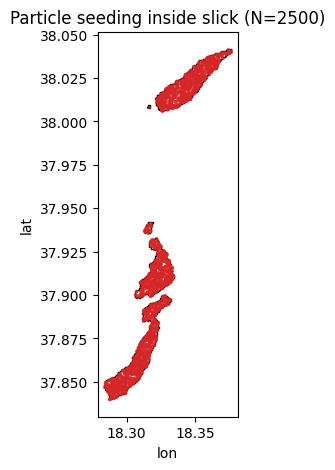

In [ ]:
# ── Cell 3: rejection-sampling seeding ───────────────────────────────────────
import shapely

def seed_particles_uniform(geom, n, rng, max_iter=200):
    minx, miny, maxx, maxy = geom.bounds
    acc_rate = geom.area / ((maxx - minx) * (maxy - miny))
    pts, it = [], 0
    while sum(len(p) for p in pts) < n and it < max_iter:
        need  = n - sum(len(p) for p in pts)
        batch = int(need / max(acc_rate, 1e-3) * 1.2) + 50
        xs = rng.uniform(minx, maxx, batch); ys = rng.uniform(miny, maxy, batch)
        keep = shapely.contains_xy(geom, xs, ys)
        pts.append(np.column_stack([xs[keep], ys[keep]]))
        it += 1
    P = np.vstack(pts)
    if len(P) < n:
        raise RuntimeError(f"Rejection sampling produced only {len(P)}/{n} particles — check geometry validity.")
    return P[:n]

particles0 = seed_particles_uniform(slick_geom, CFG["N_PARTICLES"], RNG)
print(f"Seeded {len(particles0)} particles at T0 = {T0}")
print("first 3 particles [lon, lat]:\n", particles0[:3])

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 5))
gpd.GeoSeries([slick_geom]).plot(ax=ax, facecolor="none", edgecolor="k", lw=1)
ax.scatter(particles0[:, 0], particles0[:, 1], s=2, c="tab:red", alpha=0.6)
ax.set_title(f"Particle seeding inside slick (N={len(particles0)})"); ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.set_aspect(1 / np.cos(np.radians(SLICK_INFO["centroid_lat"]))); plt.show()

## Cell 4 — Automated Met-Ocean Forcing Retrieval (CDS & CMEMS)

**Bounding box:** $[\text{lat}_{\min}-1°,\ \text{lat}_{\max}+1°]\times[\text{lon}_{\min}-1°,\ \text{lon}_{\max}+1°]$; **window:** $[T_0-\text{HOURS\_BACK}-1\text{h},\ T_0+1\text{h}]$ (one-hour buffers for interpolation).

| Source | Dataset | Variables | Notes |
|---|---|---|---|
| CDS | `reanalysis-era5-single-levels` | `u10`, `v10` | New CDS API (`https://cds.climate.copernicus.eu/api`, token key). Returns NetCDF with `valid_time` dim. |
| CMEMS | `cmems_mod_glo_phy_anfc_0.083deg_PT1H-m` | `uo`, `vo` (0.5 m depth) | Via `copernicusmarine.subset()`; credentials via env vars. |

Both datasets are normalised to a common schema (`time, latitude, longitude` ascending; lon ∈ [-180, 180]; NaN over land → 0 m/s) and wrapped in a `ForcingField` object that exposes a **trilinear interpolator** $(t, \text{lon}, \text{lat}) \mapsto (u, v)$ in m/s.

If either credential is a placeholder or a download fails, a **synthetic** field (labelled `SYNTHETIC`) is generated so the pipeline remains runnable. Do **not** use synthetic results for attribution.

In [ ]:
# ── Cell 4: forcing retrieval ────────────────────────────────────────────────
import zipfile, glob, traceback
import xarray as xr
from scipy.interpolate import RegularGridInterpolator

PAD  = CFG["BBOX_PAD_DEG"]
BBOX = {"lat_min": lat_min - PAD, "lat_max": lat_max + PAD, "lon_min": lon_min - PAD, "lon_max": lon_max + PAD}
T_START = T0 - pd.Timedelta(hours=CFG["HOURS_BACK"] + 1)
T_END   = T0 + pd.Timedelta(hours=1)
print(f"Forcing bbox: {BBOX}\nWindow: {T_START} → {T_END}")

def _is_placeholder(s): return (not s) or s.startswith("PASTE_")

# ── ERA5 via cdsapi ──────────────────────────────────────────────────────────
def setup_cds_credentials(token, url="https://cds.climate.copernicus.eu/api"):
    rc = pathlib.Path.home() / ".cdsapirc"
    rc.write_text(f"url: {url}\nkey: {token}\n")
    return rc

def fetch_era5_wind(bbox, t_start, t_end, out_dir):
    import cdsapi
    days = pd.date_range(t_start.floor("D"), t_end.floor("D"), freq="D")
    req = {
        "product_type": ["reanalysis"],
        "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
        "year":  sorted({f"{d.year:04d}" for d in days}),
        "month": sorted({f"{d.month:02d}" for d in days}),
        "day":   sorted({f"{d.day:02d}" for d in days}),
        "time":  [f"{h:02d}:00" for h in range(24)],
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": [bbox["lat_max"], bbox["lon_min"], bbox["lat_min"], bbox["lon_max"]],   # N, W, S, E
    }
    target = os.path.join(out_dir, "era5_wind.nc")
    cdsapi.Client(quiet=True).retrieve("reanalysis-era5-single-levels", req, target)
    if zipfile.is_zipfile(target):                                  # CDS sometimes wraps NetCDF in a zip
        with zipfile.ZipFile(target) as z:
            z.extractall(out_dir); member = [n for n in z.namelist() if n.endswith(".nc")][0]
        target = os.path.join(out_dir, member)
    return target

# ── CMEMS via copernicusmarine ───────────────────────────────────────────────
def fetch_cmems_currents(bbox, t_start, t_end, out_dir, dataset_id, user, pwd):
    import copernicusmarine
    os.environ["COPERNICUSMARINE_SERVICE_USERNAME"] = user
    os.environ["COPERNICUSMARINE_SERVICE_PASSWORD"] = pwd
    try:
        copernicusmarine.login(username=user, password=pwd, force_overwrite=True)
    except TypeError:
        copernicusmarine.login(username=user, password=pwd)
    out = copernicusmarine.subset(
        dataset_id=dataset_id, variables=["uo", "vo"],
        minimum_longitude=bbox["lon_min"], maximum_longitude=bbox["lon_max"],
        minimum_latitude=bbox["lat_min"], maximum_latitude=bbox["lat_max"],
        start_datetime=t_start.strftime("%Y-%m-%dT%H:%M:%S"), end_datetime=t_end.strftime("%Y-%m-%dT%H:%M:%S"),
        minimum_depth=0, maximum_depth=1,
        output_filename="cmems_currents.nc", output_directory=out_dir, disable_progress_bar=True,
    )
    return os.path.join(out_dir, "cmems_currents.nc")

# ── synthetic fallback ───────────────────────────────────────────────────────
def synthetic_forcing(bbox, t_start, t_end, kind):
    """Smooth, spatially varying, slowly rotating field. kind='wind' (~6 m/s) or 'current' (~0.25 m/s)."""
    times = pd.date_range(t_start.floor("h"), t_end.ceil("h"), freq="h")
    lats  = np.arange(bbox["lat_min"], bbox["lat_max"] + 0.25, 0.25)
    lons  = np.arange(bbox["lon_min"], bbox["lon_max"] + 0.25, 0.25)
    tt, la, lo = np.meshgrid((times - times[0]).total_seconds().values / 3600.0, lats, lons, indexing="ij")
    if kind == "wind":
        ang = np.deg2rad(225 + 20*np.sin(2*np.pi*tt/24))          # SW-ish wind veering ±20°
        spd = 6.0 + 1.5*np.sin(2*np.pi*tt/12) + 0.8*np.cos(3*lo)
        u, v = -spd*np.sin(ang), -spd*np.cos(ang)                  # 'from' direction → 'to' vector
    else:
        u = 0.25*np.cos(2*np.pi*(la - lats.mean())/2.0) + 0.05*np.sin(2*np.pi*tt/12.4)
        v = 0.15*np.sin(2*np.pi*(lo - lons.mean())/2.0) + 0.05*np.cos(2*np.pi*tt/12.4)
    return xr.Dataset({"u": (("time", "latitude", "longitude"), u), "v": (("time", "latitude", "longitude"), v)},
                      coords={"time": times, "latitude": lats, "longitude": lons}, attrs={"source": f"SYNTHETIC_{kind}"})

# ── schema normalisation ─────────────────────────────────────────────────────
def standardize(ds, u_name, v_name, source):
    ren = {}
    for cand in ["valid_time", "time_counter"]:
        if cand in ds.dims: ren[cand] = "time"
    for cand in ["lat", "y", "nav_lat"]:
        if cand in ds.dims: ren[cand] = "latitude"
    for cand in ["lon", "x", "nav_lon"]:
        if cand in ds.dims: ren[cand] = "longitude"
    ds = ds.rename({**ren, u_name: "u", v_name: "v"})
    for d in ["expver", "number", "depth"]:
        if d in ds.dims: ds = ds.isel({d: 0})
    lonv = ds.longitude.values
    if lonv.max() > 180:
        ds = ds.assign_coords(longitude=((lonv + 180) % 360) - 180)
    ds = ds.sortby("longitude").sortby("latitude").sortby("time")
    ds = ds[["u", "v"]].transpose("time", "latitude", "longitude")
    ds.attrs["source"] = source
    return ds

# ── retrieve winds ───────────────────────────────────────────────────────────
if _is_placeholder(CFG["CDS_API_KEY"]):
    print("ℹ️  CDS token not set → SYNTHETIC wind field.")
    WIND_DS = synthetic_forcing(BBOX, T_START, T_END, "wind")
else:
    try:
        setup_cds_credentials(CFG["CDS_API_KEY"])
        _p = fetch_era5_wind(BBOX, T_START, T_END, CFG["DATA_DIR"])
        WIND_DS = standardize(xr.open_dataset(_p), "u10", "v10", "ERA5").sel(time=slice(T_START, T_END)).load()
        print("✅ ERA5 winds:", _p)
    except Exception as e:
        print("❌ ERA5 download failed →", repr(e), "\n   Falling back to SYNTHETIC wind.")
        WIND_DS = synthetic_forcing(BBOX, T_START, T_END, "wind")

# ── retrieve currents ────────────────────────────────────────────────────────
if _is_placeholder(CFG["CMEMS_USERNAME"]) or _is_placeholder(CFG["CMEMS_PASSWORD"]):
    print("ℹ️  CMEMS credentials not set → SYNTHETIC current field.")
    CURR_DS = synthetic_forcing(BBOX, T_START, T_END, "current")
else:
    try:
        _p = fetch_cmems_currents(BBOX, T_START, T_END, CFG["DATA_DIR"], CFG["CMEMS_DATASET_ID"],
                                  CFG["CMEMS_USERNAME"], CFG["CMEMS_PASSWORD"])
        CURR_DS = standardize(xr.open_dataset(_p), "uo", "vo", "CMEMS").sel(time=slice(T_START, T_END)).load()
        print("✅ CMEMS currents:", _p)
    except Exception as e:
        print("❌ CMEMS download failed →", repr(e), "\n   Falling back to SYNTHETIC currents.")
        CURR_DS = synthetic_forcing(BBOX, T_START, T_END, "current")

# ── interpolator wrapper ─────────────────────────────────────────────────────
class ForcingField:
    """Trilinear (t, lat, lon) interpolator. Query in seconds relative to T0 (negative = past), lon/lat arrays. Returns m/s."""
    def __init__(self, ds, t_ref, name):
        self.name = name; self.source = ds.attrs.get("source", "?")
        t = ((ds.time.values - np.datetime64(t_ref)) / np.timedelta64(1, "s")).astype(float)
        lat, lon = ds.latitude.values.astype(float), ds.longitude.values.astype(float)
        if len(t) < 2 or len(lat) < 2 or len(lon) < 2:
            raise ValueError(f"{name}: need ≥2 samples along every axis (got t={len(t)}, lat={len(lat)}, lon={len(lon)})")
        u = np.nan_to_num(ds.u.values.astype(float)); v = np.nan_to_num(ds.v.values.astype(float))
        self.nan_frac = float(np.isnan(ds.u.values).mean())
        self.bounds = {"t": (t.min(), t.max()), "lat": (lat.min(), lat.max()), "lon": (lon.min(), lon.max())}
        self._iu = RegularGridInterpolator((t, lat, lon), u, method="linear", bounds_error=False, fill_value=None)
        self._iv = RegularGridInterpolator((t, lat, lon), v, method="linear", bounds_error=False, fill_value=None)
    def __call__(self, t_sec, lon, lat):
        lon = np.clip(np.asarray(lon, float), *self.bounds["lon"]); lat = np.clip(np.asarray(lat, float), *self.bounds["lat"])
        tt  = np.full_like(lon, np.clip(t_sec, *self.bounds["t"]))
        q   = np.column_stack([tt, lat, lon])
        return self._iu(q), self._iv(q)

WINDS    = ForcingField(WIND_DS, T0, "wind")
CURRENTS = ForcingField(CURR_DS, T0, "current")
for f in (WINDS, CURRENTS):
    print(f"{f.name:<8} source={f.source:<18} t∈[{f.bounds['t'][0]/3600:+.1f}h, {f.bounds['t'][1]/3600:+.1f}h]  "
          f"land/NaN fraction={f.nan_frac:.2%}")
_u, _v = CURRENTS(0.0, np.array([SLICK_INFO["centroid_lon"]]), np.array([SLICK_INFO["centroid_lat"]]))
_uw, _vw = WINDS(0.0, np.array([SLICK_INFO["centroid_lon"]]), np.array([SLICK_INFO["centroid_lat"]]))
print(f"At slick centroid @T0: current=({_u[0]:+.3f},{_v[0]:+.3f}) m/s   wind=({_uw[0]:+.2f},{_vw[0]:+.2f}) m/s")

Forcing bbox: {'lat_min': 36.84, 'lat_max': 39.0416, 'lon_min': 17.2834, 'lon_max': 19.3764}
Window: 2026-09-15 11:00:00 → 2026-09-16 13:00:00


19bedfccb16fe4fb4a51bd2e88763370.nc:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

✅ ERA5 winds: /content/data/era5_wind.nc


INFO - 2026-09-26T12:37:55Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.
INFO:copernicusmarine:Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.
INFO - 2026-09-26T12:37:57Z - Selected dataset version: "202406"
INFO:copernicusmarine:Selected dataset version: "202406"
INFO - 2026-09-26T12:37:57Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-09-26T12:37:57Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 0.49402499198913574]
INFO - 2026-09-26T12:38:02Z - Total size of the download: 150.50 KB.
INFO:copernicusmarine:Total size of the download: 150.50 KB.


✅ CMEMS currents: /content/data/cmems_currents.nc
wind     source=ERA5               t∈[-25.0h, +1.0h]  land/NaN fraction=0.00%
current  source=CMEMS              t∈[-25.0h, +1.0h]  land/NaN fraction=0.00%
At slick centroid @T0: current=(-0.034,-0.001) m/s   wind=(-2.47,-1.90) m/s


## Cell 5 — Reverse Lagrangian Trajectory Engine (Hindcasting)

We integrate the forward drift velocity $\vec{u}_{\text{drift}} = \vec{u}_{\text{current}} + \alpha\,\vec{u}_{\text{wind}}$ with a **4th-order Runge–Kutta** scheme and a **negative** time step $\Delta t = -600\ \text{s}$. Because $\Delta t<0$, $\vec{x}_{n+1} = \vec{x}_n + \Delta t\,\vec{u}_{\text{drift}}$ is exactly the reversed-advection equation $d\vec{x}/dt' = -\vec{u}_{\text{drift}}$ with $t'=-t$.

Velocities (m/s) are converted to angular rates on the sphere:
$$\dot\lambda = \frac{u}{R\cos\varphi}\cdot\frac{180}{\pi},\qquad \dot\varphi = \frac{v}{R}\cdot\frac{180}{\pi}$$

After each RK4 sub-step a Monte-Carlo random-walk displacement $\vec{R}\,|\Delta t|$ is added, with $R = \sqrt{6D/|\Delta t|}\;\mathcal{U}(-1,1)$ per component (variance-consistent with a diffusivity $D$).

Snapshots are stored every hour: `PARTICLE_HISTORY[k]` = positions at $T_0 - k\,\text{h}$.

In [ ]:
# ── Cell 5 (pre): Fay gravity–viscous spreading, reversed as contraction ─────
G = 9.81
CFG.update({
    "SPREADING_ENABLED": True,
    "SLICK_AGE_H":  12.0,        # assumed age of slick at T0 — UNKNOWN; sweep 6 / 12 / 24 h
    "SPREAD_MODE":  "lateral",   # 'lateral' = line discharge from a moving ship (shrinks width only)
                                 # 'radial'  = instantaneous point release (shrinks toward centroid)
    "MIN_AGE_H":    0.5,         # stop contracting below this age (Fay regime breaks down)
    "RHO_OIL": 870.0, "RHO_WATER": 1025.0, "NU_WATER": 1.0e-6, "FAY_K2": 1.45,
})
DELTA   = (CFG["RHO_WATER"] - CFG["RHO_OIL"]) / CFG["RHO_WATER"]
FAY_EXP = 0.375 if CFG["SPREAD_MODE"] == "lateral" else 0.25     # w ∝ t^3/8 (1-D) | R ∝ t^1/4 (2-D)
T_AGE0  = CFG["SLICK_AGE_H"] * 3600.0

# Sanity check: what spill volume does the observed area imply for this age? (2-D Fay, inverted)
A_obs = SLICK_INFO["area_km2"] * 1e6
V_EST = np.sqrt(A_obs**3 * np.sqrt(CFG["NU_WATER"]) / (CFG["FAY_K2"]**3 * DELTA * G * T_AGE0**1.5))
print(f"Assumed age {CFG['SLICK_AGE_H']} h → Fay-implied volume ≈ {V_EST:,.0f} m³  (plausibility check only)")

def fay_contract(X, t_model, dt):
    """Shrink the particle cloud from age (T_AGE0 + t_model) to age (T_AGE0 + t_model + dt), dt < 0."""
    age_now, age_new = T_AGE0 + t_model, T_AGE0 + t_model + dt
    if not CFG["SPREADING_ENABLED"] or age_new <= CFG["MIN_AGE_H"] * 3600:
        return X
    f = (age_new / age_now) ** FAY_EXP                       # < 1
    x, y = TO_LOCAL.transform(X[:, 0], X[:, 1])
    P = np.column_stack([x, y]); c = P.mean(0); Q = P - c
    if CFG["SPREAD_MODE"] == "radial":
        Q = Q * f
    else:                                                     # contract only across the principal axis
        axis = PCA(n_components=2).fit(Q).components_[0]; axis /= np.linalg.norm(axis)
        perp = np.array([-axis[1], axis[0]])
        Q = np.outer(Q @ axis, axis) + np.outer((Q @ perp) * f, perp)
    lon, lat = TO_WGS84.transform(*(Q + c).T)
    return np.column_stack([lon, lat])

Assumed age 12.0 h → Fay-implied volume ≈ 354,065 m³  (plausibility check only)


Integrated 144 RK4 steps (24 h) for 2500 particles.
Centroid drift T0 → T0-24h: 17.84 km (bearing 57°)
Hours stored: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


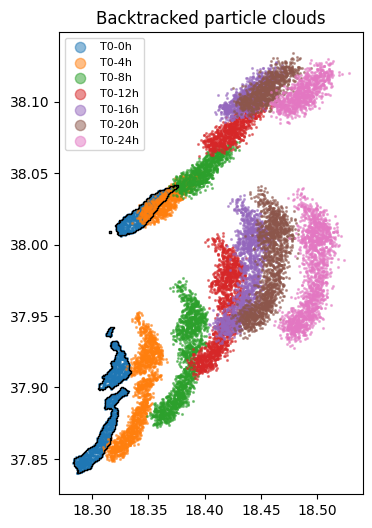

In [ ]:
# ── Cell 5: RK4 backward integrator ─────────────────────────────────────────
R_EARTH = 6_371_000.0
DT      = float(CFG["DT_SEC"]); assert DT < 0, "DT_SEC must be negative for hindcasting"
ALPHA   = CFG["ALPHA_WIND"]; D_DIFF = CFG["D_DIFF"]
STEPS_PER_HOUR = int(round(3600 / abs(DT)))
N_STEPS = CFG["HOURS_BACK"] * STEPS_PER_HOUR

def ms_to_degps(u, v, lat):
    """(m/s, m/s) → (deg/s lon, deg/s lat)."""
    return np.degrees(u / (R_EARTH * np.cos(np.radians(lat)))), np.degrees(v / R_EARTH)

def drift_velocity_deg(t_sec, X):
    """Forward drift velocity in deg/s at time t_sec (relative to T0) for particle array X=(N,2)[lon,lat]."""
    lon, lat = X[:, 0], X[:, 1]
    uc, vc = CURRENTS(t_sec, lon, lat)
    uw, vw = WINDS(t_sec, lon, lat)
    dlon, dlat = ms_to_degps(uc + ALPHA * uw, vc + ALPHA * vw, lat)
    return np.column_stack([dlon, dlat])

def rk4_step(t, X, dt):
    k1 = drift_velocity_deg(t,          X)
    k2 = drift_velocity_deg(t + dt / 2, X + dt / 2 * k1)
    k3 = drift_velocity_deg(t + dt / 2, X + dt / 2 * k2)
    k4 = drift_velocity_deg(t + dt,     X + dt * k3)
    return X + dt / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)

def random_walk_deg(X, dt, D, rng):
    R_ms  = np.sqrt(6.0 * D / abs(dt)) * rng.uniform(-1.0, 1.0, size=X.shape)     # m/s
    disp  = R_ms * abs(dt)                                                       # metres
    dlon, dlat = ms_to_degps(disp[:, 0], disp[:, 1], X[:, 1])                    # here 'deg per 1 s' == deg
    return np.column_stack([dlon, dlat])

X = particles0.copy()
PARTICLE_HISTORY = {0: X.copy()}
HOUR_TIMES = {0: T0}
t = 0.0
for step in range(1, N_STEPS + 1):
    X = rk4_step(t, X, DT)
    X = X + random_walk_deg(X, DT, D_DIFF, RNG)
    t += DT
    if step % STEPS_PER_HOUR == 0:
        k = step // STEPS_PER_HOUR
        PARTICLE_HISTORY[k] = X.copy()
        HOUR_TIMES[k] = T0 + pd.Timedelta(seconds=t)

# Diagnostics
_c0 = PARTICLE_HISTORY[0].mean(0); _cK = PARTICLE_HISTORY[CFG["HOURS_BACK"]].mean(0)
_dx, _dy = TO_LOCAL.transform(*_cK) ; _x0, _y0 = TO_LOCAL.transform(*_c0)
print(f"Integrated {N_STEPS} RK4 steps ({CFG['HOURS_BACK']} h) for {len(X)} particles.")
print(f"Centroid drift T0 → T0-{CFG['HOURS_BACK']}h: {np.hypot(_dx-_x0, _dy-_y0)/1e3:.2f} km "
      f"(bearing {np.degrees(np.arctan2(_dx-_x0, _dy-_y0))%360:.0f}°)")
print("Hours stored:", sorted(PARTICLE_HISTORY))

fig, ax = plt.subplots(figsize=(7, 6))
for k in range(0, CFG["HOURS_BACK"] + 1, max(1, CFG["HOURS_BACK"] // 6)):
    P = PARTICLE_HISTORY[k]; ax.scatter(P[:, 0], P[:, 1], s=1.5, alpha=0.5, label=f"T0-{k}h")
gpd.GeoSeries([slick_geom]).plot(ax=ax, facecolor="none", edgecolor="k")
ax.legend(markerscale=6, fontsize=8); ax.set_title("Backtracked particle clouds"); ax.set_aspect(1/np.cos(np.radians(_c0[1]))); plt.show()

## Cell 6 — Rolling Spatio-Temporal KDE Probability Envelopes

For every hindcast hour $t_k$, particles are projected to the local UTM frame (isotropic bandwidth) and a 2-D Gaussian KDE is fitted with the Silverman rule (`CFG["KDE_BW"]`). The **95 % highest-density region** is found by sorting the gridded density, taking the cumulative mass, and extracting the iso-line at the density level that encloses 95 % of the mass with **marching squares** (`contourpy`). The resulting closed contours become a `(Multi)Polygon` envelope; the distribution centroid is the particle mean.

Result: `ENVELOPES` — a `GeoDataFrame` (EPSG:4326) indexed by timestamp with `hour_back, centroid_lon, centroid_lat, area_km2, geometry`.

                     hour_back  centroid_lon  centroid_lat  area_km2 method
timestamp                                                                  
2026-09-16 12:00:00          0       18.3244       37.9334   72.4994    kde
2026-09-16 11:00:00          1       18.3291       37.9351   74.3007    kde
2026-09-16 10:00:00          2       18.3347       37.9374   75.9506    kde
2026-09-16 09:00:00          3       18.3417       37.9400   77.1767    kde
2026-09-16 08:00:00          4       18.3499       37.9431   78.7376    kde
2026-09-16 07:00:00          5       18.3588       37.9470   79.2965    kde
2026-09-16 06:00:00          6       18.3680       37.9521   79.7968    kde
2026-09-16 05:00:00          7       18.3775       37.9583   80.2607    kde
2026-09-16 04:00:00          8       18.3869       37.9658   80.7202    kde
2026-09-16 03:00:00          9       18.3957       37.9745   81.1688    kde
2026-09-16 02:00:00         10       18.4038       37.9832   81.9587    kde
2026-09-16 0

/tmp/ipykernel_735/1540693102.py:51: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.set_aspect(1/np.cos(np.radians(SLICK_INFO["centroid_lat"]))); ax.legend(); plt.show()


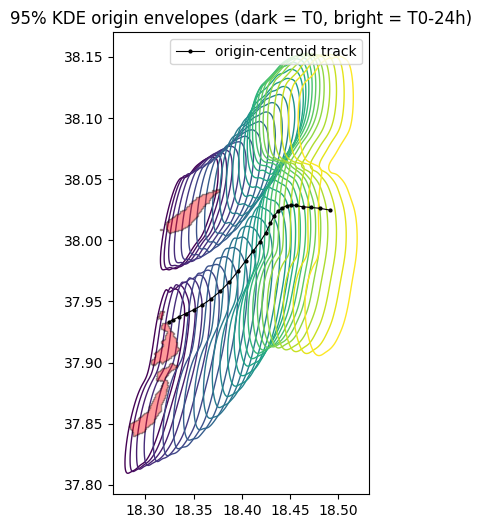

In [ ]:
# ── Cell 6: KDE envelopes ────────────────────────────────────────────────────
from scipy.stats import gaussian_kde
import contourpy
from shapely.geometry import MultiPoint

def kde_envelope(P_lonlat, level=0.95, grid_n=220, bw="silverman", pad=0.20):
    x, y = TO_LOCAL.transform(P_lonlat[:, 0], P_lonlat[:, 1])
    x, y = np.asarray(x), np.asarray(y)
    try:
        kde = gaussian_kde(np.vstack([x, y]), bw_method=bw)
        dx, dy = np.ptp(x), np.ptp(y)
        gx = np.linspace(x.min() - pad*dx, x.max() + pad*dx, grid_n)
        gy = np.linspace(y.min() - pad*dy, y.max() + pad*dy, grid_n)
        GX, GY = np.meshgrid(gx, gy)
        Z = kde(np.vstack([GX.ravel(), GY.ravel()])).reshape(GX.shape)
        zs  = np.sort(Z.ravel())[::-1]; cdf = np.cumsum(zs) / zs.sum()
        thr = zs[min(np.searchsorted(cdf, level), len(zs) - 1)]
        lines = contourpy.contour_generator(GX, GY, Z).lines(thr)
        polys = []
        for ln in lines:
            if len(ln) >= 4:
                pg = Polygon(ln).buffer(0)
                if not pg.is_empty and pg.area > 0: polys.append(pg)
        env_local = unary_union(polys) if polys else MultiPoint(np.column_stack([x, y])).convex_hull
        method = "kde"
    except Exception as e:                       # singular covariance etc. → convex hull fallback
        env_local = MultiPoint(np.column_stack([x, y])).convex_hull.buffer(50)
        method = f"hull_fallback({type(e).__name__})"
    env_wgs = shp_transform(TO_WGS84.transform, env_local)
    cx, cy  = TO_WGS84.transform(x.mean(), y.mean())
    return env_wgs, (cx, cy), env_local.area / 1e6, method

rows = []
for k in sorted(PARTICLE_HISTORY):
    env, (cx, cy), area_km2, method = kde_envelope(PARTICLE_HISTORY[k], CFG["KDE_LEVEL"], CFG["KDE_GRID_N"], CFG["KDE_BW"])
    rows.append({"timestamp": HOUR_TIMES[k], "hour_back": k, "centroid_lon": cx, "centroid_lat": cy,
                 "area_km2": area_km2, "method": method, "geometry": env})
ENVELOPES = gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326").set_index("timestamp")
ENVELOPE_BY_HOUR = dict(zip(ENVELOPES.hour_back, ENVELOPES.geometry))
CENTROID_BY_HOUR = {r.hour_back: (r.centroid_lon, r.centroid_lat) for r in ENVELOPES.itertuples()}

print(ENVELOPES[["hour_back", "centroid_lon", "centroid_lat", "area_km2", "method"]].round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
cmap = plt.get_cmap("viridis")
for r in ENVELOPES.itertuples():
    gpd.GeoSeries([r.geometry]).plot(ax=ax, facecolor="none", edgecolor=cmap(r.hour_back / CFG["HOURS_BACK"]), lw=1)
ax.plot(ENVELOPES.centroid_lon, ENVELOPES.centroid_lat, "k.-", ms=4, lw=0.8, label="origin-centroid track")
gpd.GeoSeries([slick_geom]).plot(ax=ax, facecolor="red", alpha=0.4, edgecolor="k", label="slick @T0")
ax.set_title(f"{int(CFG['KDE_LEVEL']*100)}% KDE origin envelopes (dark = T0, bright = T0-{CFG['HOURS_BACK']}h)")
ax.set_aspect(1/np.cos(np.radians(SLICK_INFO["centroid_lat"]))); ax.legend(); plt.show()

## Cell 7 — AIS Ingestion, Temporal Slicing & Spatial Screening

1. **DuckDB** reads `.parquet` / `.csv` lazily and pushes the time-window + bbox predicates down to the scan, so multi-GB regional AIS dumps never fully load into RAM. Column names are mapped via `CFG["AIS_COLUMNS"]`.
2. Each vessel's track is **linearly interpolated** to the exact hindcast timestamps $t_k$ (only when bracketing pings are ≤ `AIS_MAX_GAP_SEC` apart). SOG/COG come from the nearest raw ping.
3. **Dynamic point-in-polygon:** the interpolated position at $t_k$ is tested against the envelope for the *same* $t_k$ (`shapely.contains_xy`, vectorised). Vessels inside any envelope are flagged.

If no AIS file is present and `DEMO_MODE=True`, ~30 synthetic tracks are generated (one is planted to cross the T0-10h origin envelope so the demo produces a positive hit).

In [17]:
# ── Cell 7: AIS screening ────────────────────────────────────────────────────
import duckdb

KN2MS = 0.514444
COLS  = CFG["AIS_COLUMNS"]

def make_demo_ais(path, n_vessels=30, culprit_hour=10, ping_every_s=300):
    """Synthetic straight-line tracks across the bbox + one planted vessel crossing the T0-culprit_hour envelope centroid."""
    tgrid = np.arange(-(CFG["HOURS_BACK"] + 1) * 3600, 3600 + 1, ping_every_s, dtype=float)
    recs = []
    for i in range(n_vessels):
        mmsi = 200_000_000 + int(RNG.integers(1e7, 9e7))
        if i == 0:                                                           # planted culprit
            lon_c, lat_c = CENTROID_BY_HOUR[culprit_hour]; t_c = -culprit_hour * 3600
            brg = (SLICK_AXIS_BEARING + RNG.normal(0, 8)) % 360; sog = RNG.uniform(9, 13)
        else:
            lon_c = RNG.uniform(BBOX["lon_min"], BBOX["lon_max"]); lat_c = RNG.uniform(BBOX["lat_min"], BBOX["lat_max"])
            t_c = RNG.uniform(tgrid[0], tgrid[-1]); brg = RNG.uniform(0, 360); sog = RNG.uniform(5, 18)
        v = sog * KN2MS
        dlat = np.degrees(v * np.cos(np.radians(brg)) / R_EARTH) * (tgrid - t_c)
        dlon = np.degrees(v * np.sin(np.radians(brg)) / (R_EARTH * np.cos(np.radians(lat_c)))) * (tgrid - t_c)
        lat = lat_c + dlat + RNG.normal(0, 2e-4, len(tgrid)); lon = lon_c + dlon + RNG.normal(0, 2e-4, len(tgrid))
        recs.append(pd.DataFrame({"mmsi": mmsi, "timestamp": T0 + pd.to_timedelta(tgrid, unit="s"),
                                  "latitude": lat, "longitude": lon,
                                  "sog": sog + RNG.normal(0, 0.3, len(tgrid)), "cog": (brg + RNG.normal(0, 2, len(tgrid))) % 360}))
    df = pd.concat(recs, ignore_index=True)
    df.to_parquet(path, index=False) if path.endswith(".parquet") else df.to_csv(path, index=False)
    return df.mmsi.iloc[0]

if not os.path.exists(CFG["AIS_PATH"]):
    if CFG["DEMO_MODE"]:
        PLANTED_MMSI = make_demo_ais(CFG["AIS_PATH"])
        print(f"⚠️  No AIS file → DEMO_MODE wrote synthetic AIS to {CFG['AIS_PATH']} (planted culprit MMSI {PLANTED_MMSI})")
    else:
        raise FileNotFoundError(f"AIS file not found at {CFG['AIS_PATH']}")

# ── DuckDB ingestion with predicate push-down ────────────────────────────────
def load_ais_duckdb(path, bbox, t_start, t_end):
    reader = f"read_parquet('{path}')" if path.endswith(".parquet") else f"read_csv_auto('{path}', header=true)"
    ts_expr = f'to_timestamp("{COLS["timestamp"]}")' if CFG["AIS_TS_IS_EPOCH_SECONDS"] else f'CAST("{COLS["timestamp"]}" AS TIMESTAMP)'
    sql = f"""
        WITH src AS (
            SELECT CAST("{COLS['mmsi']}" AS BIGINT) AS mmsi, {ts_expr} AS ts,
                   CAST("{COLS['lat']}" AS DOUBLE) AS lat, CAST("{COLS['lon']}" AS DOUBLE) AS lon,
                   CAST("{COLS['sog']}" AS DOUBLE) AS sog, CAST("{COLS['cog']}" AS DOUBLE) AS cog
            FROM {reader})
        SELECT * FROM src
        WHERE ts BETWEEN TIMESTAMP '{t_start}' AND TIMESTAMP '{t_end}'
          AND lat BETWEEN {bbox['lat_min']} AND {bbox['lat_max']}
          AND lon BETWEEN {bbox['lon_min']} AND {bbox['lon_max']}
          AND mmsi IS NOT NULL AND lat IS NOT NULL AND lon IS NOT NULL
        ORDER BY mmsi, ts
    """
    con = duckdb.connect()
    df = con.execute(sql).df(); con.close()
    df["ts"] = pd.to_datetime(df["ts"]).dt.tz_localize(None)
    df["t_s"] = (df["ts"] - T0).dt.total_seconds()
    return df

AIS = load_ais_duckdb(CFG["AIS_PATH"], BBOX, T_START, T_END)
print(f"AIS pings in window+bbox: {len(AIS):,}  |  unique vessels: {AIS.mmsi.nunique()}")

# ── interpolate every vessel to the hindcast hours ───────────────────────────
HOURS = np.arange(0, CFG["HOURS_BACK"] + 1)
T_K   = -HOURS * 3600.0

def interpolate_vessel_hourly(g):
    g = g.sort_values("t_s"); ts = g.t_s.values
    if len(ts) < CFG["AIS_MIN_PINGS"]: return None
    idx  = np.clip(np.searchsorted(ts, T_K), 1, len(ts) - 1)
    gap  = ts[idx] - ts[idx - 1]
    ok   = (T_K >= ts[0]) & (T_K <= ts[-1]) & (gap <= CFG["AIS_MAX_GAP_SEC"])
    if not ok.any(): return None
    near = np.where((T_K - ts[idx - 1]) <= (ts[idx] - T_K), idx - 1, idx)
    out = pd.DataFrame({
        "mmsi": g.mmsi.iloc[0], "hour_back": HOURS, "t_s": T_K,
        "lon": np.interp(T_K, ts, g.lon.values), "lat": np.interp(T_K, ts, g.lat.values),
        "sog": g.sog.values[near], "cog": g.cog.values[near], "ping_gap_s": np.abs(T_K - ts[near]),
    })
    return out[ok]

VESSEL_HOURLY = pd.concat([d for d in (interpolate_vessel_hourly(g) for _, g in AIS.groupby("mmsi")) if d is not None],
                          ignore_index=True)
VESSEL_HOURLY["timestamp"] = T0 + pd.to_timedelta(VESSEL_HOURLY.t_s, unit="s")

# ── dynamic point-in-polygon against the matching-hour envelope ──────────────
VESSEL_HOURLY["inside_envelope"] = False
for k, env in ENVELOPE_BY_HOUR.items():
    m = VESSEL_HOURLY.hour_back == k
    if m.any():
        VESSEL_HOURLY.loc[m, "inside_envelope"] = shapely.contains_xy(env, VESSEL_HOURLY.loc[m, "lon"].values, VESSEL_HOURLY.loc[m, "lat"].values)

FLAGGED = (VESSEL_HOURLY[VESSEL_HOURLY.inside_envelope]
           .groupby("mmsi").agg(hours_inside=("hour_back", "count"), first_hour=("hour_back", "max"), last_hour=("hour_back", "min"))
           .sort_values("hours_inside", ascending=False))
print(f"\nVessels with interpolable positions: {VESSEL_HOURLY.mmsi.nunique()}")
print(f"Vessels entering a {int(CFG['KDE_LEVEL']*100)}% origin envelope at a matching hour: {len(FLAGGED)}")
print(FLAGGED.head(15).to_string() if len(FLAGGED) else "  (none flagged — scoring in Cell 8 still ranks all vessels by MDO)")

⚠️  No AIS file → DEMO_MODE wrote synthetic AIS to /content/data/ais.parquet (planted culprit MMSI 217363187)
AIS pings in window+bbox: 3,268  |  unique vessels: 30

Vessels with interpolable positions: 30
Vessels entering a 95% origin envelope at a matching hour: 2
           hours_inside  first_hour  last_hour
mmsi                                          
217363187             1          10         10
281404987             1           1          1


## Cell 8 — Culprit Attribution & Anomaly Scoring Matrix

For every screened vessel we compute, at each hindcast hour, the haversine distance between its interpolated position and the **origin centroid of the same hour**, then take the minimum → **MDO / $D_{\min}$** (this enforces *spatio-temporal* co-location, not mere spatial overlap).

| Component | Definition | Range |
|---|---|---|
| **Spatial** $S_s$ | $\exp(-D_{\min}/L_k)$, with $L_k=\max(1\ \text{km},\sqrt{A_k/\pi})$ the envelope's equivalent radius at the hour of closest approach (scale-aware) | 0–1 |
| **Temporal** $S_t$ | $0.6\,e^{-\Delta t_{\text{ping}}/1800\,\text{s}} + 0.4\min(1, h_{\text{inside}}/3)$ — evidence quality (how close a *real* ping is to $t_{k^*}$) plus persistence inside the envelope | 0–1 |
| **Course** $S_c$ | $1-\dfrac{\min(\delta,180-\delta)}{90}$, where $\delta = (\text{COG}_{k^*} - \theta_{\text{slick}}) \bmod 180$ — a slick trails along the discharging vessel's track | 0–1 |
| **Speed / manoeuvre** $S_v$ | 1.0 if anomalous (SOG < 1 kn loitering, SOG deviates > 3 kn from the vessel's median, or COG change > 30° around $k^*$); 0.6 if typical cruising 6–18 kn (deliberate discharge often happens at speed); 0.3 otherwise | {0.3, 0.6, 1.0} |

$$\text{Culprit score} = 100\,(w_s S_s + w_t S_t + w_c S_c + w_v S_v)$$

Weights are in `CFG`. The output `SUSPECTS` DataFrame is ranked by score.

In [18]:
# ── Cell 8: scoring ──────────────────────────────────────────────────────────
def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2 - lon1)/2)**2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

def circ_diff(a, b, period=360.0):
    d = np.abs((a - b) % period); return np.minimum(d, period - d)

_env = ENVELOPES.reset_index()[["hour_back", "centroid_lon", "centroid_lat", "area_km2"]]
VH = VESSEL_HOURLY.merge(_env, on="hour_back", how="left")
VH["dist_km"] = haversine_km(VH.lon, VH.lat, VH.centroid_lon, VH.centroid_lat)

def score_vessel(g):
    g = g.sort_values("hour_back")
    i = int(g.dist_km.values.argmin()); r = g.iloc[i]; k = int(r.hour_back)
    # spatial
    L  = max(1.0, np.sqrt(r.area_km2 / np.pi)); S_s = float(np.exp(-r.dist_km / L))
    # temporal
    hours_inside = int(g.inside_envelope.sum())
    S_t = 0.6 * float(np.exp(-r.ping_gap_s / 1800.0)) + 0.4 * min(1.0, hours_inside / 3.0)
    # course alignment (axial)
    dev = circ_diff(r.cog, SLICK_AXIS_BEARING, 180.0); S_c = float(1.0 - dev / 90.0)
    # speed / manoeuvre profile
    med_sog = float(g.sog.median())
    nb = g[(g.hour_back >= k - 1) & (g.hour_back <= k + 1)]
    cog_change = float(circ_diff(nb.cog.values[:-1], nb.cog.values[1:]).max()) if len(nb) > 1 else 0.0
    loiter = r.sog < 1.0; speed_dev = abs(r.sog - med_sog) > 3.0; turn = cog_change > 30.0
    anomalous = bool(loiter or speed_dev or turn)
    S_v = 1.0 if anomalous else (0.6 if 6.0 <= r.sog <= 18.0 else 0.3)
    score = 100 * (CFG["W_SPATIAL"]*S_s + CFG["W_TEMPORAL"]*S_t + CFG["W_COURSE"]*S_c + CFG["W_SPEED"]*S_v)
    return pd.Series({
        "MDO_km": round(float(r.dist_km), 3), "closest_hour_back": k, "time_closest_approach": r.timestamp,
        "lon_closest": r.lon, "lat_closest": r.lat, "sog_kn": round(float(r.sog), 1), "cog_deg": round(float(r.cog), 1),
        "cog_vs_slick_axis_deg": round(dev, 1), "hours_inside_envelope": hours_inside, "ping_gap_s": int(r.ping_gap_s),
        "manoeuvre_flag": ("loiter " if loiter else "") + ("speed_dev " if speed_dev else "") + ("turn>30° " if turn else "") or "cruising",
        "S_spatial": round(S_s, 3), "S_temporal": round(S_t, 3), "S_course": round(S_c, 3), "S_speed": round(S_v, 3),
        "culprit_score_pct": round(float(score), 1),
    })

try:
    _scored = VH.groupby("mmsi").apply(score_vessel, include_groups=False)     # pandas ≥ 2.2
except TypeError:
    _scored = VH.groupby("mmsi").apply(score_vessel)                           # older pandas
SUSPECTS = _scored.sort_values("culprit_score_pct", ascending=False).reset_index()
SUSPECTS.insert(0, "rank", np.arange(1, len(SUSPECTS) + 1))
TOP = SUSPECTS.head(CFG["TOP_N_SUSPECTS"])
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
print(f"Slick axis bearing used for course alignment: {SLICK_AXIS_BEARING:.1f}°\n")
print(TOP.to_string(index=False))
if "PLANTED_MMSI" in globals():
    print(f"\n(DEMO) planted culprit MMSI {PLANTED_MMSI} ranked #{int(SUSPECTS.loc[SUSPECTS.mmsi == PLANTED_MMSI, 'rank'].iloc[0])}")

Slick axis bearing used for course alignment: 13.4°

 rank      mmsi  MDO_km  closest_hour_back time_closest_approach  lon_closest  lat_closest  sog_kn  cog_deg  cog_vs_slick_axis_deg  hours_inside_envelope  ping_gap_s manoeuvre_flag  S_spatial  S_temporal  S_course  S_speed  culprit_score_pct
    1 217363187   0.034                 10   2026-09-16 02:00:00    18.403926    37.982872    10.0      9.5                    3.9                      1           0       cruising      0.993       0.733     0.957      0.6               87.5
    2 266336628  14.202                  4   2026-09-16 08:00:00    18.506478    37.910536     6.8    189.6                    3.7                      0           0       cruising      0.059       0.600     0.959      0.6               42.8
    3 281404987   8.554                  1   2026-09-16 11:00:00    18.306843    37.860228    11.0    239.6                   46.2                      1           0       cruising      0.172       0.733     0.486      0.

## Cell 9 — Interactive Map Visualisation (Folium)

Layers (toggle via the control in the top-right):
* **Oil slick @T0** — vectorised satellite mask.
* **KDE 95 % envelopes** — colour ramp from $T_0$ (dark) to $T_0-24$h (light), one polygon per hour with tooltips.
* **Origin centroids** — hourly KDE centroids joined into a drift track.
* **Suspect tracks (top N)** — raw AIS trajectories of the ranked suspects, coloured by rank, with a marker at the time/position of closest approach. Tooltips show MMSI, rank, score, MDO, SOG/COG and closest-approach time.

The map is also saved to `DATA_DIR/suspect_map.html` for sharing.

In [ ]:
# ── Cell 9: folium map ───────────────────────────────────────────────────────
import folium, branca.colormap as bcm
from folium.plugins import MeasureControl, Fullscreen

center = [SLICK_INFO["centroid_lat"], SLICK_INFO["centroid_lon"]]
m = folium.Map(location=center, zoom_start=10, tiles="CartoDB positron", control_scale=True)
folium.TileLayer("OpenStreetMap", name="OSM").add_to(m)
folium.TileLayer("Esri.WorldImagery", name="Esri satellite").add_to(m)

# 1) slick polygon
fg_slick = folium.FeatureGroup(name="Oil slick @T0", show=True)
folium.GeoJson(gpd.GeoSeries([slick_geom], crs="EPSG:4326").__geo_interface__,
               style_function=lambda f: {"color": "black", "weight": 1.5, "fillColor": "#d62728", "fillOpacity": 0.55},
               tooltip=f"Detected slick  T0={T0:%Y-%m-%d %H:%M}Z  area={SLICK_INFO['area_km2']:.2f} km²").add_to(fg_slick)
fg_slick.add_to(m)

# 2) KDE envelopes + 3) centroids
cmap = bcm.LinearColormap(["#08306b", "#2171b5", "#6baed6", "#fdae6b", "#e6550d"], vmin=0, vmax=CFG["HOURS_BACK"], caption="Hours before T0")
fg_env = folium.FeatureGroup(name=f"KDE {int(CFG['KDE_LEVEL']*100)}% origin envelopes", show=True)
fg_cen = folium.FeatureGroup(name="Origin centroids (drift track)", show=True)
for r in ENVELOPES.itertuples():
    col = cmap(r.hour_back)
    folium.GeoJson(gpd.GeoSeries([r.geometry], crs="EPSG:4326").__geo_interface__,
                   style_function=(lambda c: (lambda f: {"color": c, "weight": 1.2, "fillColor": c, "fillOpacity": 0.08}))(col),
                   tooltip=f"T0-{r.hour_back}h  ({r.Index:%Y-%m-%d %H:%M}Z)  area={r.area_km2:.1f} km²").add_to(fg_env)
    folium.CircleMarker([r.centroid_lat, r.centroid_lon], radius=3, color=col, fill=True, fill_opacity=1,
                        tooltip=f"Centroid T0-{r.hour_back}h ({r.centroid_lat:.4f}, {r.centroid_lon:.4f})").add_to(fg_cen)
folium.PolyLine([[r.centroid_lat, r.centroid_lon] for r in ENVELOPES.sort_values("hour_back").itertuples()],
                color="black", weight=1, dash_array="4", opacity=0.7).add_to(fg_cen)
fg_env.add_to(m); fg_cen.add_to(m); cmap.add_to(m)

# 4) suspect tracks
rank_cmap = bcm.LinearColormap(["#b10026", "#fc4e2a", "#feb24c"], vmin=1, vmax=max(2, len(TOP)))
fg_sus = folium.FeatureGroup(name=f"Suspect vessel tracks (top {len(TOP)})", show=True)
for s in TOP.itertuples():
    trk = AIS[AIS.mmsi == s.mmsi].sort_values("ts")
    col = rank_cmap(s.rank)
    tip = (f"<b>Rank #{s.rank} — MMSI {s.mmsi}</b><br>Culprit score: {s.culprit_score_pct:.1f}%<br>"
           f"MDO: {s.MDO_km:.2f} km @ T0-{s.closest_hour_back}h<br>Closest approach: {s.time_closest_approach:%Y-%m-%d %H:%M}Z<br>"
           f"SOG {s.sog_kn} kn · COG {s.cog_deg}° (Δaxis {s.cog_vs_slick_axis_deg}°)<br>"
           f"Hours in envelope: {s.hours_inside_envelope} · manoeuvre: {s.manoeuvre_flag}")
    folium.PolyLine(trk[["lat", "lon"]].values.tolist(), color=col, weight=3 if s.rank <= 3 else 2, opacity=0.9, tooltip=tip).add_to(fg_sus)
    folium.Marker([s.lat_closest, s.lon_closest], tooltip=tip,
                  icon=folium.DivIcon(html=f'<div style="font-size:11px;font-weight:bold;color:white;background:{col};'
                                           f'border-radius:10px;padding:1px 5px;white-space:nowrap">#{s.rank} {s.mmsi}</div>')).add_to(fg_sus)
    folium.CircleMarker([s.lat_closest, s.lon_closest], radius=6, color="black", weight=1, fill=True, fill_color=col, fill_opacity=1).add_to(fg_sus)
fg_sus.add_to(m)

# 5) all screened AIS (sampled, off by default)
fg_all = folium.FeatureGroup(name="All screened AIS pings (sampled)", show=False)
for lat_, lon_, mm in AIS.sample(min(len(AIS), 3000), random_state=0)[["lat", "lon", "mmsi"]].values:
    folium.CircleMarker([lat_, lon_], radius=1, color="#555", opacity=0.4, tooltip=str(int(mm))).add_to(fg_all)
fg_all.add_to(m)

folium.LayerControl(collapsed=False).add_to(m); MeasureControl().add_to(m); Fullscreen().add_to(m)
m.fit_bounds([[BBOX["lat_min"] + 0.5, BBOX["lon_min"] + 0.5], [BBOX["lat_max"] - 0.5, BBOX["lon_max"] - 0.5]])
MAP_PATH = os.path.join(CFG["DATA_DIR"], "suspect_map.html"); m.save(MAP_PATH)
print("Map saved →", MAP_PATH)
m

## Cell 10 (optional) — Export Results

Writes the ranked suspects, the hourly vessel/envelope matrix and the KDE envelopes to disk for downstream reporting or GIS.

In [ ]:
# ── Cell 10: exports ─────────────────────────────────────────────────────────
out = pathlib.Path(CFG["DATA_DIR"])
SUSPECTS.to_csv(out / "suspects_ranked.csv", index=False)
VH.to_csv(out / "vessel_hourly_matrix.csv", index=False)
ENVELOPES.reset_index().to_file(out / "kde_envelopes.geojson", driver="GeoJSON")
gpd.GeoSeries([slick_geom], crs="EPSG:4326").to_file(out / "slick_polygon.geojson", driver="GeoJSON")
pd.DataFrame({"hour_back": [k for k in PARTICLE_HISTORY for _ in range(len(particles0))],
              "lon": np.concatenate([PARTICLE_HISTORY[k][:, 0] for k in PARTICLE_HISTORY]),
              "lat": np.concatenate([PARTICLE_HISTORY[k][:, 1] for k in PARTICLE_HISTORY])}).to_parquet(out / "particles_hourly.parquet", index=False)
print("Exports written to", out, ":", sorted(p.name for p in out.iterdir()))

In [ ]:
# ── Cell 12: simulation video (forward re-run and/or backward hindcast) ──────
import matplotlib.pyplot as plt, matplotlib.animation as animation
from matplotlib.patches import Patch
import shutil

CFG.update({
    "VIDEO_MODE":      "both",   # 'forward' | 'backward' | 'both'
    "VIDEO_FPS":       10,
    "VIDEO_FRAME_MIN": 20,       # minutes of simulated time per frame
    "VIDEO_DPI":       110,
    "VIDEO_SHOW_SUSPECT": True,  # overlay the rank-1 vessel from Cell 8
})
STEPS_PER_FRAME = max(1, int(round(CFG["VIDEO_FRAME_MIN"] * 60 / abs(DT))))

def simulate(X0, t_start, t_end, dt, rng):
    # Integrate particles from t_start to t_end (seconds rel. T0) with the Cell-5 engine
    X, t, frames = X0.copy(), float(t_start), [(float(t_start), X0.copy())]
    n = int(round(abs(t_end - t_start) / abs(dt)))
    for step in range(1, n + 1):
        X = rk4_step(t, X, dt) + random_walk_deg(X, dt, D_DIFF, rng)
        t += dt
        if step % STEPS_PER_FRAME == 0 or step == n:
            frames.append((t, X.copy()))
    return frames

# Fixed viewport covering everything the backtrack visited
_all = np.vstack(list(PARTICLE_HISTORY.values()))
_pad = 0.08 * max(np.ptp(_all[:, 0]), np.ptp(_all[:, 1]))
XLIM = (_all[:, 0].min() - _pad, _all[:, 0].max() + _pad); YLIM = (_all[:, 1].min() - _pad, _all[:, 1].max() + _pad)

# Rank-1 suspect track for overlay
_sus_track = None
if CFG["VIDEO_SHOW_SUSPECT"] and "SUSPECTS" in globals() and len(SUSPECTS):
    _mm = int(SUSPECTS.iloc[0].mmsi)
    _g = AIS[AIS.mmsi == _mm].sort_values("t_s")
    _sus_track = (_mm, _g.t_s.values, _g.lon.values, _g.lat.values)

def render_video(frames, title, out_path):
    fig, ax = plt.subplots(figsize=(6.4, 6.4 * (YLIM[1]-YLIM[0]) / ((XLIM[1]-XLIM[0]) * np.cos(np.radians(np.mean(YLIM))))))
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect(1 / np.cos(np.radians(np.mean(YLIM))))
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(alpha=0.25)
    gpd.GeoSeries([slick_geom]).plot(ax=ax, facecolor="none", edgecolor="black", lw=1.4, zorder=3)
    sc = ax.scatter([], [], s=3, c=[], cmap="viridis", vmin=-CFG["HOURS_BACK"], vmax=0, alpha=0.75, zorder=2)
    ship, = ax.plot([], [], marker=(3, 0, 0), ms=11, color="crimson", ls="", zorder=4)
    trail, = ax.plot([], [], color="crimson", lw=1, alpha=0.6, zorder=4)
    stamp = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top", fontsize=10,
                    bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))
    handles = [Patch(facecolor="none", edgecolor="black", label="Observed slick @T0")]
    if _sus_track: handles.append(plt.Line2D([], [], color="crimson", marker=">", ls="", label=f"Suspect MMSI {_sus_track[0]}"))
    ax.legend(handles=handles, loc="lower right", fontsize=8)
    fig.suptitle(title, fontsize=12)

    def draw(i):
        t, X = frames[i]
        sc.set_offsets(X); sc.set_array(np.full(len(X), t / 3600))
        stamp.set_text(f"{(T0 + pd.Timedelta(seconds=t)):%Y-%m-%d %H:%M} UTC   (T0 {t/3600:+.1f} h)")
        if _sus_track:
            mm, ts, lo, la = _sus_track
            if ts[0] <= t <= ts[-1]:
                ship.set_data([np.interp(t, ts, lo)], [np.interp(t, ts, la)])
                m = ts <= t; trail.set_data(lo[m], la[m])
            else:
                ship.set_data([], []); trail.set_data([], [])
        return sc, ship, trail, stamp

    anim = animation.FuncAnimation(fig, draw, frames=len(frames), interval=1000 / CFG["VIDEO_FPS"], blit=False)
    if shutil.which("ffmpeg"):
        anim.save(out_path, writer=animation.FFMpegWriter(fps=CFG["VIDEO_FPS"], bitrate=2400,
                  extra_args=["-pix_fmt", "yuv420p", "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2"]), dpi=CFG["VIDEO_DPI"])
    else:
        out_path = out_path.replace(".mp4", ".gif")
        anim.save(out_path, writer=animation.PillowWriter(fps=CFG["VIDEO_FPS"]), dpi=CFG["VIDEO_DPI"] // 2)
    plt.close(fig)
    return out_path

VIDEOS = {}
_rng = np.random.default_rng(CFG["RANDOM_SEED"] + 1)
if CFG["VIDEO_MODE"] in ("backward", "both"):
    fr = simulate(particles0, 0.0, -CFG["HOURS_BACK"] * 3600, DT, _rng)
    VIDEOS["backward"] = render_video(fr, f"Backward hindcast  T0 → T0-{CFG['HOURS_BACK']}h",
                                      os.path.join(CFG["DATA_DIR"], "backward_simulation.mp4"))
if CFG["VIDEO_MODE"] in ("forward", "both"):
    X_origin = PARTICLE_HISTORY[CFG["HOURS_BACK"]]                 # start from the backtracked origin cloud
    fr = simulate(X_origin, -CFG["HOURS_BACK"] * 3600, 0.0, abs(DT), _rng)
    VIDEOS["forward"] = render_video(fr, f"Forward re-simulation  T0-{CFG['HOURS_BACK']}h → T0",
                                     os.path.join(CFG["DATA_DIR"], "forward_simulation.mp4"))
for k, v in VIDEOS.items():
    print(f"{k:<9} → {v}  ({os.path.getsize(v)/1e6:.1f} MB, {len(fr)} frames)")

# Preview inline in Colab
try:
    from IPython.display import Video, display
    for v in VIDEOS.values():
        if v.endswith(".mp4"): display(Video(v, embed=True, width=520))
except Exception:
    pass